# Module 2: Embedding-Based Retrieval — Theory & Math

> **Series:** PyTorch Deep Dive → BERT Fine-Tuning for Embedding-Based Retrieval  
> **Prerequisites:** Module 1 (tensors, autograd, `nn.Module`)

---

## What you'll learn

| # | Section |
|---|---------|
| 1 | Sparse vs dense retrieval |
| 2 | Vector spaces & similarity metrics |
| 3 | Contrastive learning: InfoNCE & triplet loss |
| 4 | BERT as an encoder & the anisotropy problem |

Every equation is implemented in plain PyTorch so you can feel the math, not just read it.


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

torch.manual_seed(0)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")


Device: mps


---
## 1 · Sparse vs Dense Retrieval

### The classic approach: sparse representations

Traditional IR systems represent text as **sparse bags of words**:

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count}(t,d)}{|d|}}_{\text{TF}} \times \underbrace{\log\frac{N}{|\{d : t \in d\}|}}_{\text{IDF}}$$

| Symbol | Meaning |
|--------|---------|
| $t$ | A specific term (word) |
| $d$ | A specific document |
| $\text{count}(t, d)$ | Number of times term $t$ appears in document $d$ |
| $\|d\|$ | Total number of terms in document $d$ (document length) — dividing by this normalises for longer documents |
| $N$ | Total number of documents in the corpus |
| $\|\{d : t \in d\}\|$ | Number of documents that contain term $t$ (document frequency) |
| $\log \frac{N}{\|\{d : t \in d\}\|}$ | **IDF** — rare terms get high weight; terms that appear in every document (e.g. "the") get near-zero weight |

**BM25** (used by Elasticsearch, Lucene) improves TF-IDF with document length normalisation.

**Limitations of sparse retrieval:**
- Vocabulary mismatch: "car" ≠ "automobile"
- No semantic understanding
- Cannot capture paraphrase or context

### The dense approach

Map both queries and documents into a shared **dense vector space** using a neural encoder $f_\theta$:

$$q^* = f_\theta(q), \quad d^* = f_\theta(d) \in \mathbb{R}^h$$

Retrieval = **nearest neighbour search** in that space.

#### Shared encoder (Siamese) vs dual encoder

The notation $f_\theta$ for both sides implies a **shared-weight (Siamese) encoder** — the same model with the same parameters processes both queries and documents. This is the most common architecture in practice:

| Architecture | Query encoder | Doc encoder | Used in |
|---|---|---|---|
| **Shared / Siamese** | $f_\theta$ | $f_\theta$ (same weights) | SBERT, SimCSE, most academic work |
| **Dual encoder** | $f_{\theta_q}$ | $f_{\theta_d}$ (separate weights) | DPR, some production systems |
| **Asymmetric** | small $f_{\theta_q}$ | large $f_{\theta_d}$ | Hypothetical; rarely used |

**Why shared weights are common:**
- Queries and documents are both natural language — there's no strong reason to use different representations
- Half the parameters to train and store
- Easier to generalise: the encoder learns a *universal* semantic space rather than two aligned-but-separate ones
- Works well empirically (SBERT, SimCSE both use shared weights)

**Why dual encoders are sometimes preferred:**
- Queries are typically short (5–15 tokens); documents can be hundreds of tokens — the distribution mismatch may justify separate specialised encoders
- DPR (Dense Passage Retrieval) uses two separate BERT models and found this gave slightly better results on open-domain QA
- In production, you may want to quantise or distil the **query encoder** aggressively (since it runs online on every user request, so latency is critical) while keeping the doc encoder full-precision (it runs as an offline batch job, so accuracy matters more than speed)

> **In Module 3 we use a shared encoder** — one BERT model encoding both queries and passages, which is the simpler and more commonly reproduced setup.


---
## 2 · Similarity Metrics

### Dot product

$$s_{\text{dot}}(\mathbf{q}, \mathbf{d}) = \mathbf{q}^\top \mathbf{d} = \sum_{i=1}^{h} q_i d_i$$

Fast and unbounded. Sensitive to embedding **magnitude** — models can "cheat" by inflating norms.

### Cosine similarity

$$s_{\text{cos}}(\mathbf{q}, \mathbf{d}) = \frac{\mathbf{q}^\top \mathbf{d}}{\|\mathbf{q}\| \cdot \|\mathbf{d}\|}$$

Normalises out magnitude — only **direction** matters. Equivalent to dot product on L2-normalised vectors.

### When to use which?

| | Dot product | Cosine Similarity|
|--|-------------|--------|
| Speed | Slightly faster | Needs normalisation step |
| Used in | DPR, ColBERT | SBERT, SimCSE |
| Risk | Norm inflation | None (already normalised) |


In [3]:
# Implement and compare similarity functions
def dot_product(q: torch.Tensor, d: torch.Tensor) -> torch.Tensor:
    """Batch dot product: (B, h) x (B, h) → (B,)"""
    return (q * d).sum(dim=-1)

def cosine_similarity(q: torch.Tensor, d: torch.Tensor) -> torch.Tensor:
    """Cosine similarity: normalise then dot product."""
    q_norm = F.normalize(q, p=2, dim=-1)
    d_norm = F.normalize(d, p=2, dim=-1)
    return (q_norm * d_norm).sum(dim=-1)

# Demo: same direction, different magnitude
q = torch.tensor([[1.0, 0.0]])
d_same_dir  = torch.tensor([[5.0, 0.0]])  # same direction, 5x larger
d_different = torch.tensor([[0.0, 1.0]])  # orthogonal

print("Query          :", q[0].tolist())
print("Same direction :", d_same_dir[0].tolist())
print(f"  dot product  : {dot_product(q, d_same_dir).item():.2f}")
print(f"  cosine       : {cosine_similarity(q, d_same_dir).item():.2f}  ← magnitude-insensitive")

print("\nOrthogonal     :", d_different[0].tolist())
print(f"  dot product  : {dot_product(q, d_different).item():.2f}")
print(f"  cosine       : {cosine_similarity(q, d_different).item():.2f}")


Query          : [1.0, 0.0]
Same direction : [5.0, 0.0]
  dot product  : 5.00
  cosine       : 1.00  ← magnitude-insensitive

Orthogonal     : [0.0, 1.0]
  dot product  : 0.00
  cosine       : 0.00


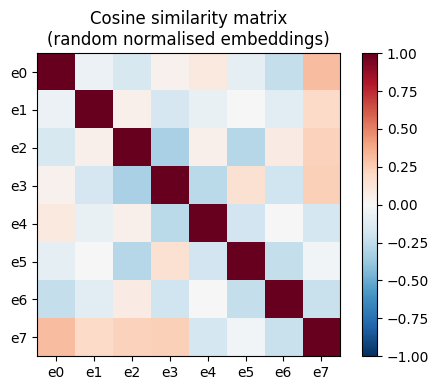

In [4]:
# Visualise a similarity matrix between random embeddings
N, h = 8, 32
embeddings = F.normalize(torch.randn(N, h), dim=-1)   # L2-normalised
sim_matrix  = embeddings @ embeddings.T                 # (N, N) — cosine sim

labels = [f"e{i}" for i in range(N)]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix.numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_title("Cosine similarity matrix\n(random normalised embeddings)")
plt.tight_layout(); plt.show()


---
## 3 · Contrastive Learning

### The intuition

We want the embedding space to satisfy:

$$s(q, d^+) \gg s(q, d^-)$$

where $d^+$ is a relevant document and $d^-$ is not. Training achieves this by **pulling** positive pairs together and **pushing** negatives apart.

### InfoNCE Loss (used in DPR, SimCSE)

Given a batch of $N$ (query, positive-document) pairs, the negatives are all *other* documents in the same batch (**in-batch negatives**):

$$\mathcal{L}_{\text{InfoNCE}} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(s(q_i, d_i^+) / \tau)}{\sum_{j=1}^{N} \exp(s(q_i, d_j) / \tau)}$$

- $\tau$ is a **temperature** hyperparameter (typically 0.05–0.1)

**Intuition — what does dividing by $\tau$ actually do?**

The softmax inside the log turns the raw similarities into a probability distribution over all $N$ documents. Dividing by $\tau$ *scales* the logits before that softmax:

$$p_{ij} = \frac{\exp(s_{ij}/\tau)}{\sum_k \exp(s_{ik}/\tau)}$$

| $\tau$ | Effect on logits | Resulting distribution | Training signal |
|--------|-----------------|----------------------|-----------------|
| Very low (e.g. 0.01) | Magnified — small similarity differences become huge | Almost one-hot on the highest-scoring doc | Very hard: near-zero gradient unless the positive is already ranked #1 |
| Typical (0.05–0.1) | Moderate scaling | Peaked but not one-hot | Strong, stable signal |
| High (e.g. 1.0) | Logits barely change | Nearly uniform | Weak: loss is high but gradients are small and noisy |

**Why not just set $\tau$ as low as possible?**  
At very low temperatures the loss becomes near-zero once the positive is ranked #1, even slightly — the model receives almost no gradient to *further* separate the positive from near-miss negatives. It can also cause numerical instability (overflow before the `exp` is computed). In practice $\tau = 0.07$ is a common default (used in SimCSE, MoCo).

This is exactly cross-entropy over $N$ classes where class $i$ is the correct positive for query $i$.

### Triplet Loss

$$\mathcal{L}_{\text{triplet}} = \frac{1}{N}\sum_{i=1}^{N} \max\!\left(0,\; \|q_i - d_i^+\|^2 - \|q_i - d_i^-\|^2 + \alpha\right)$$

$\alpha$ is the **margin** — how much closer the positive must be than the negative before the loss becomes zero.


In [5]:
def info_nce_loss(q: torch.Tensor, d: torch.Tensor, temperature: float = 0.07) -> torch.Tensor:
    """
    InfoNCE (in-batch negatives).

    Args:
        q: query embeddings  (N, h) — L2-normalised
        d: doc   embeddings  (N, h) — L2-normalised
        temperature: τ

    Returns:
        scalar loss
    """
    # (N, N) similarity matrix — diagonal = positive pairs
    logits = (q @ d.T) / temperature       # s(qᵢ, dⱼ) / τ

    # Cross-entropy: target for row i is column i (the positive)
    targets = torch.arange(len(q), device=q.device)
    return F.cross_entropy(logits, targets)


def triplet_loss(q: torch.Tensor, d_pos: torch.Tensor,
                 d_neg: torch.Tensor, margin: float = 0.2) -> torch.Tensor:
    """
    Triplet loss with L2 distance.

    Args:
        q, d_pos, d_neg: embeddings (N, h)
        margin: α
    """
    dist_pos = torch.norm(q - d_pos, dim=-1) ** 2
    dist_neg = torch.norm(q - d_neg, dim=-1) ** 2
    return torch.clamp(dist_pos - dist_neg + margin, min=0).mean()


# Demonstrate: after training, positive sim should be high
N, h = 16, 64
q     = F.normalize(torch.randn(N, h), dim=-1)
d_pos = F.normalize(q + 0.1 * torch.randn(N, h), dim=-1)   # close to q
d_neg = F.normalize(torch.randn(N, h), dim=-1)              # random

loss_nce     = info_nce_loss(q, d_pos, temperature=0.07)
loss_triplet = triplet_loss(q, d_pos, d_neg, margin=0.2)

print(f"InfoNCE loss  : {loss_nce.item():.4f}  (lower = positives are more separated from negatives)")
print(f"Triplet loss  : {loss_triplet.item():.4f}")


InfoNCE loss  : 0.0010  (lower = positives are more separated from negatives)
Triplet loss  : 0.0000


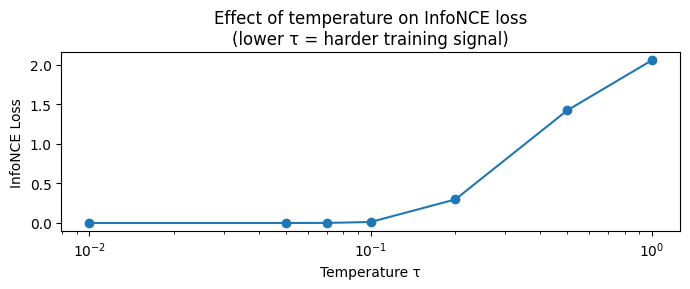

In [6]:
# How does temperature τ affect the loss landscape?
temps = [0.01, 0.05, 0.07, 0.1, 0.2, 0.5, 1.0]
losses = [info_nce_loss(q, d_pos, t).item() for t in temps]

plt.figure(figsize=(7, 3))
plt.plot(temps, losses, marker="o")
plt.xlabel("Temperature τ"); plt.ylabel("InfoNCE Loss")
plt.title("Effect of temperature on InfoNCE loss\n(lower τ = harder training signal)")
plt.xscale("log"); plt.tight_layout(); plt.show()


---
## 4 · BERT as an Encoder

### Transformer architecture quick recap

BERT processes a token sequence through $L$ Transformer layers. Each layer applies:

1. **Multi-head self-attention** — tokens attend to each other
2. **Feed-forward network** — per-token transformation
3. **Residual + LayerNorm** — stabilise training

The output is a sequence of contextual token representations of shape `(batch, seq_len, hidden_size)`.

### Pooling strategies

To get a **single sentence embedding** from the token sequence:

| Strategy | How | Pros / Cons |
|----------|-----|-------------|
| `[CLS]` token | Use position 0 | Simple; pre-trained to aggregate | Loses token details |
| Mean pooling | Average all token embeddings | Usually better for retrieval | Slightly slower |
| Max pooling | Take element-wise max | Captures peak activation | Less common |

### The anisotropy problem

Vanilla BERT embeddings occupy a **narrow cone** in the embedding space — most embeddings point in nearly the same direction, making cosine similarity uninformative. This is why fine-tuning is necessary.

### Bi-encoder vs Cross-encoder

```
Bi-encoder  : f(query) · f(doc)        → precompute doc embeddings, O(1) at query time
Cross-encoder: f(query ⊕ doc) → score  → must re-run for every (query, doc) pair, O(N) at query time
```

For large-scale retrieval we always use a **bi-encoder** (possibly with a cross-encoder reranker on top).


In [ ]:
import torch.nn as nn

class MeanPoolingEncoder(nn.Module):
    """
    Wraps any HuggingFace-style transformer and applies mean pooling
    over non-padding token representations.
    """

    def __init__(self, hidden_size: int = 768, embedding_dim: int = 256):
        super().__init__()
        # Projection head — reduces dimensionality and adds trainable capacity
        self.proj = nn.Sequential(
            nn.Linear(hidden_size, embedding_dim),
            nn.LayerNorm(embedding_dim),
        )

    def mean_pool(self, token_embeddings: torch.Tensor,
                  attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Average token embeddings, ignoring padding tokens.

        token_embeddings : (B, L, H)
        attention_mask   : (B, L)  — 1 for real tokens, 0 for padding
        """
        mask = attention_mask.unsqueeze(-1).float()          # (B, L, 1)
        sum_emb   = (token_embeddings * mask).sum(dim=1)     # (B, H)
        sum_mask  = mask.sum(dim=1).clamp(min=1e-9)          # (B, 1)
        return sum_emb / sum_mask

    def forward(self, token_embeddings: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        pooled = self.mean_pool(token_embeddings, attention_mask)  # (B, H)
        return F.normalize(self.proj(pooled), p=2, dim=-1)         # (B, D) L2-normalised


# Simulate what BERT would output
B, L, H = 4, 32, 768
fake_bert_output = torch.randn(B, L, H)
mask = torch.ones(B, L, dtype=torch.long)
mask[:, 20:] = 0   # last 12 tokens are padding

encoder = MeanPoolingEncoder(hidden_size=H, embedding_dim=256)
emb = encoder(fake_bert_output, mask)
print(f"Output embeddings shape : {emb.shape}")        # (4, 256)
print(f"L2 norms (should be 1) : {emb.norm(dim=-1)}")  # all ≈ 1.0


---
## Summary

| Concept | Key takeaway |
|---------|-------------|
| Sparse retrieval | Fast but vocabulary-limited |
| Dense retrieval | Semantic, requires fine-tuned encoder |
| Dot product | Fast; sensitive to embedding magnitude |
| Cosine similarity | Magnitude-invariant; preferred for normalised embeddings |
| InfoNCE | Cross-entropy over in-batch negatives; temperature controls sharpness |
| Triplet loss | Explicit (q, d⁺, d⁻) triples; needs hard negative mining for strong signal |
| Bi-encoder | Index docs offline → O(1) retrieval; that's what we train in Module 3 |

**Next:** [Module 3 — Fine-Tuning BERT for Retrieval](03_finetune_bert_retrieval.ipynb)
